In [1]:
## Access Openai key stored in Colab secrets :
from google.colab import userdata
openai = userdata.get('OPENAI')

## set as environment variable :
import os
os.environ["OPENAI_API_KEY"] = openai

In [2]:
!pip install langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 6.1 MB/s eta 0:00:00


In [3]:
from langchain_openai import OpenAI

llm = OpenAI()

In [ ]:
# /content/attention-is-all-you-need-Paper.pdf

In [4]:
!pip install pypdf langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.7/333.7 kB 21.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 69.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 46.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.7 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [5]:
## Document Loader :
from langchain_community.document_loaders import PyPDFLoader

loader = PyPDFLoader("/content/attention-is-all-you-need-Paper.pdf")
pages = loader.load()

In [6]:
pages

[Document(metadata={'producer': 'PyPDF2', 'creator': 'PyPDF', 'creationdate': '', 'subject': 'Neural Information Processing Systems http://nips.cc/', 'publisher': 'Curran Associates, Inc.', 'language': 'en-US', 'created': '2017', 'eventtype': 'Poster', 'description-abstract': 'The dominant sequence transduction models are based on complex recurrent orconvolutional neural networks in an encoder and decoder configuration. The best performing such models also connect the encoder and decoder through an attentionm echanisms.  We propose a novel, simple network architecture based solely onan attention mechanism, dispensing with recurrence and convolutions entirely.Experiments on two machine translation tasks show these models to be superiorin quality while being more parallelizable and requiring significantly less timeto train. Our single model with 165 million parameters, achieves 27.5 BLEU onEnglish-to-German translation, improving over the existing best ensemble result by over 1 BLEU. On 

In [7]:
page_content = ""

for page in pages:
  page_content += page.page_content

In [8]:
Prompt = f"""You are a helpful assistant, specialized in summarization
your task is to create clear & concise summary of given document
Document : {page_content}
Summary :
"""

In [9]:
llm.invoke(Prompt)

BadRequestError: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens, however you requested 8537 tokens (8281 in your prompt; 256 for the completion). Please reduce your prompt; or completion length.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [12]:
from langchain_classic.chains import load_summarize_chain

chain = load_summarize_chain(llm=llm,
                            #  chain_type="",

                             )

In [11]:
chain.invoke(pages)

BadRequestError: Error code: 400 - {'error': {'message': "This model's maximum context length is 4097 tokens, however you requested 8533 tokens (8277 in your prompt; 256 for the completion). Please reduce your prompt; or completion length.", 'type': 'invalid_request_error', 'param': None, 'code': None}}

In [ ]:
# chain_type --> how llm will process data

In [ ]:
# default : chain_type="stuff"

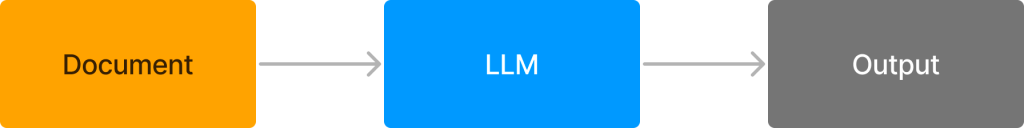

In [13]:
from IPython.display import Image
Image("/content/Chain_type_Stuff.png")

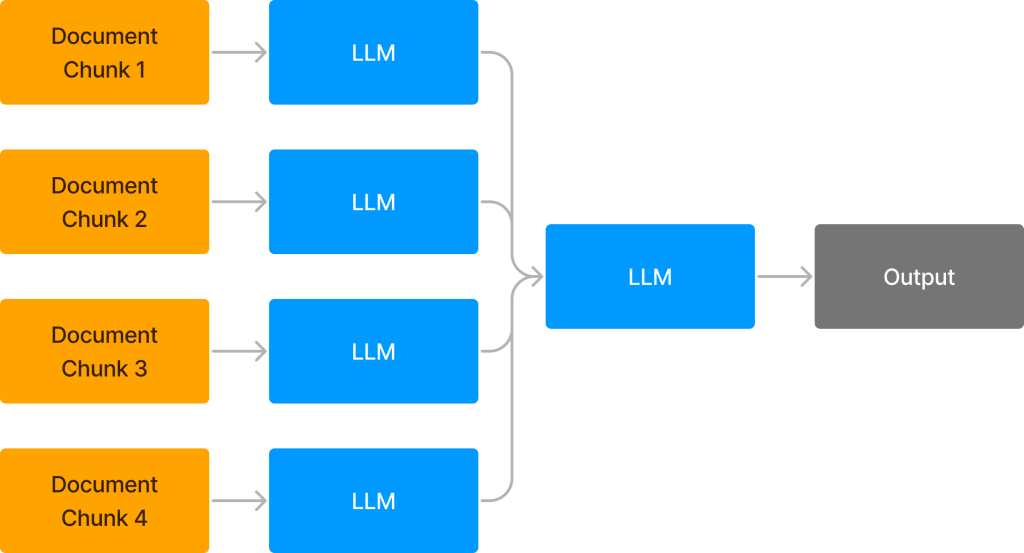

In [16]:
##map_reduce :
Image("/content/chain_type_map_reduce.png", width=300)

In [17]:
chain = load_summarize_chain(llm=llm,
                             chain_type="map_reduce",

                             )

In [19]:
output = chain.invoke(pages)

In [20]:
output["output_text"]

'\n\nThe article discusses a new neural network architecture called the Transformer, which uses only attention mechanisms and no recurrent or convolutional layers. It outperforms existing models in terms of quality, parallelizability, and training time, and has achieved state-of-the-art performance in translation tasks. The model uses self-attention and multi-head attention, and has an encoder-decoder structure with stacked layers. Experiments show the effectiveness of the model and variations were tested to evaluate different components. The code is available online. The article also provides a list of references for related research on deep learning and neural networks.'

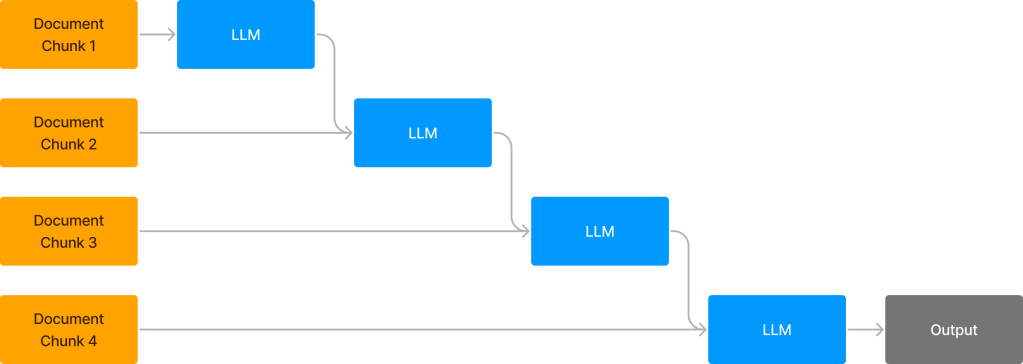

In [22]:
## Refine :
Image("/content/Chain_type_refine.png", width=300)

In [23]:
chain = load_summarize_chain(llm=llm,
                             chain_type="refine",
                             )

In [25]:
output = chain.invoke(pages)

In [26]:
output["output_text"]

'\n\nThe paper "Attention Is All You Need" introduces the Transformer, a new neural network architecture that utilizes attention mechanisms instead of traditional recurrent or convolutional neural networks. The Transformer relies entirely on self-attention and follows an encoder-decoder structure with stacked self-attention and fully connected layers. The attention function used is the "Scaled Dot-Product Attention," which computes a weighted sum of values based on the query and key vectors. The paper also introduces the concept of multi-head attention, which allows the model to jointly attend to information from different representation subspaces at different positions. This approach is more efficient and effective than traditional single head attention methods. The model architecture, as shown in Figure 1, consists of stacked encoder and decoder layers with residual connections and layer normalization. The decoder also includes a third sub-layer for multi-head attention over the outp

In [ ]:
"stuff" --> default

Pros :
      -- All data us processed in one shot, no informtion loss
      -- Single LLM call


Cons :
      -- Context window limit
      -- can not process large document

In [ ]:
"map_reduce"

Pros :
      -- Can handle large document
      -- It is faster than refine


Cons :
      -- Multiple LLM Calls
      -- Some information may be missing

In [ ]:
"refine"

Pros :
      -- Can handle large document
      -- less information loss compared to map_reduce


Cons :
      -- Multiple LLM Calls
      -- It is slower than map_reduce